# Common Statistical Tests: z, t, Chi-Square, and F

## Learning Objectives

By the end of this notebook you will be able to:

1. Perform a **z-test** for a population mean when $\sigma$ is known, and derive the test statistic from the CLT.
2. Conduct **two-sample z-tests** for comparing two population means.
3. Explain why the **t-test** is needed when $\sigma$ is unknown, and perform one-sample, two-sample, and paired t-tests.
4. Apply **Welch's correction** for unequal variances and know when it is appropriate.
5. Use the **chi-square test** for goodness-of-fit and for independence in contingency tables.
6. Perform an **F-test** for equality of variances and understand its connection to ANOVA.
7. Implement each test **from scratch** in NumPy and verify against `scipy.stats`.
8. Choose the **correct test** for a given research question.

## Prerequisites

- [01_hypothesis_framework.ipynb](01_hypothesis_framework.ipynb) — Null/alternative hypotheses, p-values, significance level
- [Module 02](../02_distributions/02_continuous_distributions.ipynb) — Normal, t, chi-square, and F distributions
- [Module 04](../04_estimation/04_confidence_intervals.ipynb) — Sampling distributions, standard error, CLT

In [ ]:
import sys, os, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system(
        "sudo apt-get update -qq && sudo apt-get install -y -qq "
        "libcairo2-dev libpango1.0-dev && pip install -q manim ipython==8.21.0"
    )

_miktex_bin = Path.home() / "AppData/Local/Programs/MiKTeX/miktex/bin/x64"
if _miktex_bin.exists() and str(_miktex_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + str(_miktex_bin)

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import apply_style

apply_style()


class Cfg:
    root = Path("../../").resolve()
    gif_dir = root / "media" / "gifs"
    has_latex: bool = (
        shutil.which("latex") is not None or shutil.which("pdflatex") is not None
    )

    def __init__(self):
        self.gif_dir.mkdir(parents=True, exist_ok=True)

    def apply_manim_config(self):
        from manim import config as mcfg

        mcfg.format = "gif"

    def math_text(self, expr, **kwargs):
        from manim import MathTex, Text

        if self.has_latex:
            return MathTex(expr, **kwargs)
        return Text(expr, **kwargs)

    def save_gifs(self, clean=True):
        local_media = Path("media")
        found = list(local_media.rglob("*.gif")) if local_media.exists() else []
        if not found:
            print("  No new GIFs to save.")
            return
        for gif in found:
            dest = self.gif_dir / gif.name
            shutil.copy2(gif, dest)
            print(f"  \u2713 media/gifs/{gif.name}")
        if clean:
            for sub in ("videos", "images", "Tex"):
                d = local_media / sub
                if d.exists():
                    shutil.rmtree(d, ignore_errors=True)
            print("  Cleaned up local temp render files (kept media/jupyter/).")


cfg = Cfg()
rng = np.random.default_rng(42)

---

## 1. The z-Test for a Population Mean (Known $\sigma$)

### Setting

We have a random sample $X_1, X_2, \ldots, X_n$ from a population with **known** standard deviation $\sigma$, and we want to test whether the population mean $\mu$ equals some hypothesised value $\mu_0$:

$$H_0: \mu = \mu_0 \qquad \text{vs.} \qquad H_1: \mu \neq \mu_0$$

### Derivation from the Central Limit Theorem

By the CLT, the sampling distribution of the sample mean is:

$$\bar{X} \sim \mathcal{N}\!\left(\mu,\, \frac{\sigma^2}{n}\right) \quad \text{(exactly if the population is Normal; approximately for large } n \text{)}$$

Under $H_0$ (i.e., $\mu = \mu_0$), we can standardise:

$$Z = \frac{\bar{X} - \mu_0}{\sigma / \sqrt{n}} \sim \mathcal{N}(0, 1)$$

This is the **z-test statistic**. It measures how many standard errors the sample mean is from the hypothesised value.

**In plain language:** We compute the sample mean, subtract the value we're testing against, and divide by the standard error (which is $\sigma / \sqrt{n}$, how much the sample mean naturally fluctuates). If this ratio is large in absolute value, the data is far from what $H_0$ predicts.

### Decision rules

| Alternative | Reject $H_0$ if | p-value |
|---|---|---|
| $H_1: \mu \neq \mu_0$ (two-sided) | $|Z| > z_{\alpha/2}$ | $2\,\Phi(-|z_{\text{obs}}|)$ |
| $H_1: \mu > \mu_0$ (right-sided) | $Z > z_{\alpha}$ | $1 - \Phi(z_{\text{obs}})$ |
| $H_1: \mu < \mu_0$ (left-sided) | $Z < -z_{\alpha}$ | $\Phi(z_{\text{obs}})$ |

where $\Phi$ is the standard normal CDF and $z_{\alpha}$ is the $1 - \alpha$ quantile.

### Worked Example

A bottling machine fills bottles with a target volume of $\mu_0 = 500$ mL. From past calibration, the standard deviation is known to be $\sigma = 8$ mL. A quality inspector takes a sample of $n = 36$ bottles and measures a sample mean of $\bar{x} = 497.5$ mL. Is the machine under-filling?

**Step 1 — Hypotheses:**
$$H_0: \mu = 500 \qquad H_1: \mu < 500 \quad \text{(one-sided, since we're worried about under-filling)}$$

**Step 2 — Significance level:** $\alpha = 0.05$

**Step 3 — Test statistic:**
$$Z = \frac{\bar{x} - \mu_0}{\sigma / \sqrt{n}} = \frac{497.5 - 500}{8 / \sqrt{36}} = \frac{-2.5}{1.333} = -1.875$$

**Step 4 — p-value:** Since $H_1: \mu < 500$ (left-sided), $p = \Phi(z_{\text{obs}}) = \Phi(-1.875)$.

In [ ]:
# Worked example: one-sample z-test (known sigma)
mu_0 = 500  # hypothesised mean
sigma = 8  # known population std
n = 36
xbar = 497.5  # sample mean

# Step 3: test statistic
se = sigma / np.sqrt(n)
z_obs = (xbar - mu_0) / se
print(f"Standard error: {se:.4f}")
print(f"Z = ({xbar} - {mu_0}) / {se:.4f} = {z_obs:.4f}")

# Step 4: p-value (left-sided)
p_value = stats.norm.cdf(z_obs)
print(f"p-value (left-sided) = {p_value:.4f}")

# Step 5: decision
alpha = 0.05
print(f"\nalpha = {alpha}")
if p_value <= alpha:
    print(f"p = {p_value:.4f} <= {alpha} => REJECT H0")
    print(
        "Conclusion: There is significant evidence that the machine is under-filling."
    )
else:
    print(f"p = {p_value:.4f} > {alpha} => FAIL TO REJECT H0")
    print("Conclusion: Insufficient evidence that the machine is under-filling.")

Standard error: 1.3333
Z = (497.5 - 500) / 1.3333 = -1.8750
p-value (left-sided) = 0.0304

alpha = 0.05
p = 0.0304 <= 0.05 => REJECT H0
Conclusion: There is significant evidence that the machine is under-filling.


With $p \approx 0.030 < 0.05$, we reject $H_0$. There is statistically significant evidence that the machine is under-filling.

### From-Scratch Implementation

In [3]:
def z_test_one_sample(sample_mean, mu_0, sigma, n, alternative="two-sided"):
    """
    One-sample z-test (known population sigma).

    Parameters
    ----------
    sample_mean : float
        Observed sample mean.
    mu_0 : float
        Hypothesised population mean under H0.
    sigma : float
        Known population standard deviation.
    n : int
        Sample size.
    alternative : str
        'two-sided', 'greater', or 'less'.

    Returns
    -------
    z_stat : float
    p_value : float
    """
    se = sigma / np.sqrt(n)
    z_stat = (sample_mean - mu_0) / se

    if alternative == "two-sided":
        p_value = 2 * stats.norm.sf(abs(z_stat))
    elif alternative == "greater":
        p_value = stats.norm.sf(z_stat)
    elif alternative == "less":
        p_value = stats.norm.cdf(z_stat)
    else:
        raise ValueError(f"Unknown alternative: {alternative}")

    return z_stat, p_value


# Verify with worked example
z, p = z_test_one_sample(497.5, 500, 8, 36, alternative="less")
print(f"From scratch:  z = {z:.4f}, p = {p:.4f}")

# Two-sided version
z2, p2 = z_test_one_sample(497.5, 500, 8, 36, alternative="two-sided")
print(f"Two-sided:     z = {z2:.4f}, p = {p2:.4f}")

From scratch:  z = -1.8750, p = 0.0304
Two-sided:     z = -1.8750, p = 0.0608


**Note:** `scipy.stats` does not have a standalone one-sample z-test function (because the z-test is rarely used in practice — we almost never know $\sigma$). The from-scratch version above is the standard approach. For the two-sample z-test, scipy does have `statsmodels.stats.weightstats.ztest`, but our implementation is transparent.

---

## 2. Two-Sample z-Test

### Setting

We have two independent samples:
- Sample 1: $X_1, \ldots, X_{n_1}$ from a population with mean $\mu_1$ and **known** $\sigma_1$
- Sample 2: $Y_1, \ldots, Y_{n_2}$ from a population with mean $\mu_2$ and **known** $\sigma_2$

We test:
$$H_0: \mu_1 = \mu_2 \qquad \text{vs.} \qquad H_1: \mu_1 \neq \mu_2$$

### Derivation

Under $H_0$, the difference $\bar{X} - \bar{Y}$ has mean 0 and, by independence:

$$\text{Var}(\bar{X} - \bar{Y}) = \text{Var}(\bar{X}) + \text{Var}(\bar{Y}) = \frac{\sigma_1^2}{n_1} + \frac{\sigma_2^2}{n_2}$$

So the **pooled standard error** is:

$$\text{SE} = \sqrt{\frac{\sigma_1^2}{n_1} + \frac{\sigma_2^2}{n_2}}$$

And the test statistic:

$$Z = \frac{\bar{X} - \bar{Y}}{\sqrt{\frac{\sigma_1^2}{n_1} + \frac{\sigma_2^2}{n_2}}} \sim \mathcal{N}(0, 1)$$

**In plain language:** We take the difference of the two sample means and divide by how much that difference would naturally fluctuate due to sampling. If the populations have the same mean, this ratio should be close to zero.

### Worked Example

A factory has two production lines. From historical records:
- Line A: $\sigma_1 = 3.2$ grams
- Line B: $\sigma_2 = 2.8$ grams

We sample $n_1 = 40$ items from Line A ($\bar{x}_1 = 52.3$ g) and $n_2 = 35$ items from Line B ($\bar{x}_2 = 50.8$ g). Is there a difference?

In [ ]:
def z_test_two_sample(xbar1, xbar2, sigma1, sigma2, n1, n2, alternative="two-sided"):
    """
    Two-sample z-test for difference of means (known sigmas).
    """
    se = np.sqrt(sigma1**2 / n1 + sigma2**2 / n2)
    z_stat = (xbar1 - xbar2) / se

    if alternative == "two-sided":
        p_value = 2 * stats.norm.sf(abs(z_stat))
    elif alternative == "greater":
        p_value = stats.norm.sf(z_stat)
    elif alternative == "less":
        p_value = stats.norm.cdf(z_stat)
    else:
        raise ValueError(f"Unknown alternative: {alternative}")

    return z_stat, p_value, se


# Factory example
xbar1, xbar2 = 52.3, 50.8
sigma1, sigma2 = 3.2, 2.8
n1, n2 = 40, 35

z, p, se = z_test_two_sample(xbar1, xbar2, sigma1, sigma2, n1, n2)
print(f"Difference of means: {xbar1} - {xbar2} = {xbar1 - xbar2:.1f}")
print(f"Pooled SE = sqrt({sigma1}^2/{n1} + {sigma2}^2/{n2}) = {se:.4f}")
print(f"Z = {z:.4f}")
print(f"p-value (two-sided) = {p:.4f}")
print(f"\nAt alpha = 0.05: {'REJECT H0' if p < 0.05 else 'Fail to reject H0'}")
print(
    f"Conclusion: The two production lines {'do' if p < 0.05 else 'may not'} have different mean weights."
)

Difference of means: 52.3 - 50.8 = 1.5
Pooled SE = sqrt(3.2^2/40 + 2.8^2/35) = 0.6928
Z = 2.1651
p-value (two-sided) = 0.0304

At alpha = 0.05: REJECT H0
Conclusion: The two production lines do have different mean weights.


---

## 3. One-Sample t-Test (Unknown $\sigma$)

### Why Do We Need a Different Test?

In the z-test, we used the **known** population standard deviation $\sigma$ in the denominator. In practice, $\sigma$ is almost never known. The natural idea is to replace $\sigma$ with the sample standard deviation $s$:

$$T = \frac{\bar{X} - \mu_0}{s / \sqrt{n}}$$

But here's the problem: $s$ is itself a random variable computed from the same data. Replacing the fixed $\sigma$ with the random $s$ introduces **extra uncertainty**. The resulting statistic $T$ is *more variable* than a standard normal — it has heavier tails.

### Historical Note: William Sealy Gosset ("Student")

This problem was solved in 1908 by **William Sealy Gosset**, a chemist and statistician at the Guinness brewery in Dublin. Guinness had a policy forbidding employees from publishing under their own names (to prevent trade secrets from leaking), so Gosset published under the pseudonym **"Student"**.

Gosset was working with small samples of barley and hops and realised that the normal approximation was inadequate. He derived the exact distribution of $T$ when sampling from a normal population, which we now call **Student's t-distribution**.

The mathematical proof of its exact distribution was later provided by R.A. Fisher in 1925.

### Derivation

Let $X_1, \ldots, X_n \sim \mathcal{N}(\mu, \sigma^2)$ (i.i.d.). Then:

$$\bar{X} \sim \mathcal{N}\!\left(\mu,\, \frac{\sigma^2}{n}\right), \qquad \frac{(n-1)S^2}{\sigma^2} \sim \chi^2_{n-1}, \qquad \bar{X} \perp S^2$$

where $S^2 = \frac{1}{n-1}\sum_{i=1}^n (X_i - \bar{X})^2$ is the sample variance. The independence of $\bar{X}$ and $S^2$ is a special property of the normal distribution (a consequence of the Basu’s theorem or direct computation via orthogonal projections).

Now, under $H_0: \mu = \mu_0$:

$$Z = \frac{\bar{X} - \mu_0}{\sigma / \sqrt{n}} \sim \mathcal{N}(0, 1)$$

$$V = \frac{(n-1)S^2}{\sigma^2} \sim \chi^2_{n-1}$$

The t-statistic is the ratio:

$$T = \frac{Z}{\sqrt{V/(n-1)}} = \frac{\bar{X} - \mu_0}{\sigma / \sqrt{n}} \cdot \frac{1}{S / \sigma} = \frac{\bar{X} - \mu_0}{S / \sqrt{n}} \sim t_{n-1}$$

This is a standard normal divided by the square root of an independent chi-squared divided by its degrees of freedom — which is the **definition** of the t-distribution with $n - 1$ degrees of freedom.

### Degrees of Freedom — Intuition

The parameter $\nu = n - 1$ is called the **degrees of freedom** (df). Why $n - 1$?

When we compute $S^2$, we use $\bar{X}$ in place of the unknown $\mu$. But $\bar{X}$ was computed from the same $n$ data points, which imposes one **constraint**: the deviations $X_i - \bar{X}$ must sum to zero ($\sum (X_i - \bar{X}) = 0$). So only $n - 1$ of these deviations are free to vary — the last one is determined by the others. Hence $n - 1$ degrees of freedom.

**As $n$ grows:** The t-distribution with large df looks increasingly like $\mathcal{N}(0, 1)$. For $n \geq 30$, the difference is small; for $n > 100$, it's negligible. This is because with lots of data, $S \approx \sigma$ with little uncertainty.

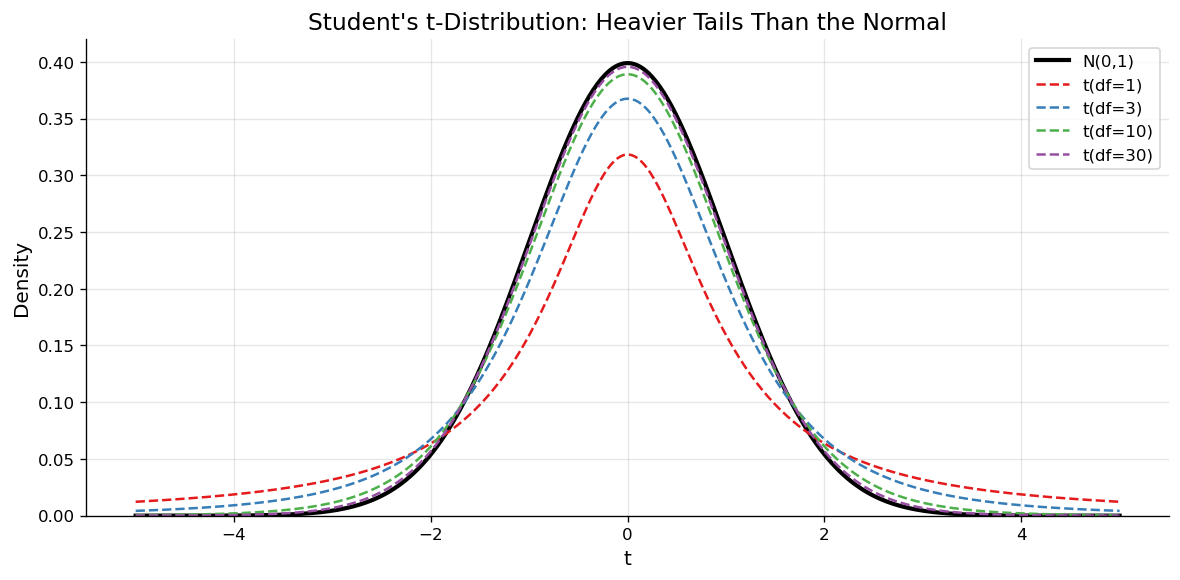

In [ ]:
# Visualise: t-distribution vs normal for different df
fig, ax = plt.subplots(figsize=(10, 5))
x = np.linspace(-5, 5, 500)

ax.plot(x, stats.norm.pdf(x), "k-", linewidth=2.5, label="N(0,1)")

colors = ["#E41A1C", "#377EB8", "#4DAF4A", "#984EA3"]
for df, c in zip([1, 3, 10, 30], colors):
    ax.plot(
        x,
        stats.t.pdf(x, df),
        color=c,
        linewidth=1.5,
        linestyle="--",
        label=f"t(df={df})",
    )

ax.set_xlabel("t")
ax.set_ylabel("Density")
ax.set_title("Student's t-Distribution: Heavier Tails Than the Normal")
ax.legend(fontsize=10)
ax.set_ylim(0, 0.42)
plt.tight_layout()
plt.show()

The t-distribution has heavier tails, especially for small df. This means:
- Critical values are **larger** than the z-test (e.g., $t_{0.025, 5} = 2.571$ vs. $z_{0.025} = 1.960$).
- The t-test requires **more extreme** data to reject $H_0$ — it's more conservative.
- This extra conservatism properly accounts for the uncertainty in estimating $\sigma$.

### Worked Example

A manufacturer claims their light bulbs last $\mu_0 = 1000$ hours on average. We test $n = 15$ bulbs and measure:

$$\bar{x} = 978, \qquad s = 40$$

Is there evidence that bulbs last less than claimed? ($H_1: \mu < 1000$)

In [ ]:
# Worked example: one-sample t-test
mu_0 = 1000
n = 15
xbar = 978
s = 40
alpha = 0.05
df = n - 1

# Step-by-step calculation
se = s / np.sqrt(n)
t_obs = (xbar - mu_0) / se

# p-value (left-sided)
p_value = stats.t.cdf(t_obs, df=df)

# Critical value
t_crit = stats.t.ppf(alpha, df=df)

print(f"Sample: n = {n}, x-bar = {xbar}, s = {s}")
print(f"SE = s / sqrt(n) = {s} / sqrt({n}) = {se:.4f}")
print(f"t = ({xbar} - {mu_0}) / {se:.4f} = {t_obs:.4f}")
print(f"df = {df}")
print(f"\np-value (left-sided) = {p_value:.4f}")
print(f"Critical value at alpha = {alpha}: t_crit = {t_crit:.4f}")
print(
    f"\nComparison: t_obs = {t_obs:.4f} {'<' if t_obs < t_crit else '>'} t_crit = {t_crit:.4f}"
)
print(f"Decision: {'REJECT H0' if p_value <= alpha else 'FAIL TO REJECT H0'}")

# Compare with z-test to see the difference
p_z = stats.norm.cdf(t_obs)
print(f"\n--- If we (incorrectly) used the z-test: p = {p_z:.4f} ---")
print(f"The t-test p-value ({p_value:.4f}) is larger because t has heavier tails.")

Sample: n = 15, x-bar = 978, s = 40
SE = s / sqrt(n) = 40 / sqrt(15) = 10.3280
t = (978 - 1000) / 10.3280 = -2.1301
df = 14

p-value (left-sided) = 0.0257
Critical value at alpha = 0.05: t_crit = -1.7613

Comparison: t_obs = -2.1301 < t_crit = -1.7613
Decision: REJECT H0

--- If we (incorrectly) used the z-test: p = 0.0166 ---
The t-test p-value (0.0257) is larger because t has heavier tails.


### From-Scratch Implementation vs. scipy

In [ ]:
def t_test_one_sample_scratch(data, mu_0, alternative="two-sided"):
    """
    One-sample t-test from scratch.

    Parameters
    ----------
    data : array-like
        Sample observations.
    mu_0 : float
        Hypothesised population mean.
    alternative : str
        'two-sided', 'greater', or 'less'.

    Returns
    -------
    t_stat, p_value, df
    """
    data = np.asarray(data, dtype=float)
    n = len(data)
    df = n - 1
    xbar = data.mean()
    s = data.std(ddof=1)  # sample std with Bessel's correction
    se = s / np.sqrt(n)
    t_stat = (xbar - mu_0) / se

    if alternative == "two-sided":
        p_value = 2 * stats.t.sf(abs(t_stat), df=df)
    elif alternative == "greater":
        p_value = stats.t.sf(t_stat, df=df)
    elif alternative == "less":
        p_value = stats.t.cdf(t_stat, df=df)
    else:
        raise ValueError(f"Unknown alternative: {alternative}")

    return t_stat, p_value, df


# Generate sample data for demonstration
sample_bulbs = rng.normal(loc=978, scale=40, size=15)

# From scratch
t_s, p_s, df_s = t_test_one_sample_scratch(sample_bulbs, mu_0=1000, alternative="less")
print(f"From scratch:  t = {t_s:.4f}, p = {p_s:.4f}, df = {df_s}")

# scipy
t_sp, p_sp = stats.ttest_1samp(sample_bulbs, popmean=1000)
# scipy gives two-sided p-value; for one-sided left, divide by 2 if t < 0
p_sp_left = p_sp / 2 if t_sp < 0 else 1 - p_sp / 2
print(
    f"scipy:         t = {t_sp:.4f}, p = {p_sp_left:.4f}, df = {len(sample_bulbs) - 1}"
)
print(f"\nMatch: {np.isclose(t_s, t_sp) and np.isclose(p_s, p_sp_left)}")

From scratch:  t = -2.3268, p = 0.0177, df = 14
scipy:         t = -2.3268, p = 0.0177, df = 14

Match: True


---

## 4. Two-Sample t-Test

### Setting

Two independent samples, but now $\sigma_1$ and $\sigma_2$ are **unknown**:

$$H_0: \mu_1 = \mu_2 \qquad \text{vs.} \qquad H_1: \mu_1 \neq \mu_2$$

There are two cases, depending on whether we can assume $\sigma_1 = \sigma_2$.

### Case 1: Equal Variances (Pooled t-Test)

If we assume $\sigma_1 = \sigma_2 = \sigma$ (unknown), we can **pool** the two samples to get a better estimate of the common variance:

$$S_p^2 = \frac{(n_1 - 1)S_1^2 + (n_2 - 1)S_2^2}{n_1 + n_2 - 2}$$

This is the **pooled sample variance** — a weighted average of the two sample variances, where the weights are the degrees of freedom. It makes sense: if both samples estimate the same $\sigma^2$, combining them gives a more precise estimate.

The test statistic is:

$$T = \frac{\bar{X}_1 - \bar{X}_2}{S_p \sqrt{\frac{1}{n_1} + \frac{1}{n_2}}} \sim t_{n_1 + n_2 - 2}$$

The degrees of freedom are $n_1 + n_2 - 2$ because we estimated one parameter ($\mu$) from each sample.

### Case 2: Unequal Variances (Welch's t-Test)

If we **cannot** assume equal variances, we use **Welch's approximation** (1947). The test statistic is:

$$T = \frac{\bar{X}_1 - \bar{X}_2}{\sqrt{\frac{S_1^2}{n_1} + \frac{S_2^2}{n_2}}}$$

The distribution of $T$ is approximately $t_\nu$ where the degrees of freedom $\nu$ are given by the **Welch–Satterthwaite equation**:

$$\nu = \frac{\left(\frac{S_1^2}{n_1} + \frac{S_2^2}{n_2}\right)^2}{\frac{(S_1^2/n_1)^2}{n_1 - 1} + \frac{(S_2^2/n_2)^2}{n_2 - 1}}$$

This $\nu$ is generally not an integer, and it's always between $\min(n_1, n_2) - 1$ and $n_1 + n_2 - 2$.

**In plain language:** The Welch–Satterthwaite formula adjusts the degrees of freedom downward to account for the fact that the two variances are different. When the variances differ a lot, $\nu$ is much smaller than $n_1 + n_2 - 2$, making the test more conservative (harder to reject). When the variances are equal, it reduces approximately to the pooled df.

### When to Use Which?

| Condition                                                         | Recommended test             |
|-------------------------------------------------------------------|------------------------------|
| Known that $\sigma_1 = \sigma_2$ (e.g., same measurement process) | Pooled t-test                |
| Unsure or unequal variances                                       | **Welch's t-test** (default) |

**Welch's test is almost always preferred** in practice. It performs nearly as well as the pooled test when variances are equal, but much better when they're not. Many statisticians (and scipy's default) use Welch's as the standard.

### Worked Example

Two teaching methods are compared. Test scores:

In [ ]:
# Generate two groups of test scores
method_A = rng.normal(loc=72, scale=8, size=25)
method_B = rng.normal(loc=78, scale=12, size=30)

print(
    f"Method A: n = {len(method_A)}, mean = {method_A.mean():.2f}, std = {method_A.std(ddof=1):.2f}"
)
print(
    f"Method B: n = {len(method_B)}, mean = {method_B.mean():.2f}, std = {method_B.std(ddof=1):.2f}"
)

Method A: n = 25, mean = 72.50, std = 6.26
Method B: n = 30, mean = 78.99, std = 8.74


In [ ]:
def t_test_two_sample_scratch(data1, data2, equal_var=False, alternative="two-sided"):
    """
    Two-sample t-test from scratch.

    Parameters
    ----------
    data1, data2 : array-like
        Two independent samples.
    equal_var : bool
        If True, use pooled variance. If False, use Welch's.
    alternative : str
        'two-sided', 'greater', or 'less'.

    Returns
    -------
    t_stat, p_value, df
    """
    d1 = np.asarray(data1, dtype=float)
    d2 = np.asarray(data2, dtype=float)
    n1, n2 = len(d1), len(d2)
    xbar1, xbar2 = d1.mean(), d2.mean()
    s1_sq, s2_sq = d1.var(ddof=1), d2.var(ddof=1)

    if equal_var:
        # Pooled variance
        sp_sq = ((n1 - 1) * s1_sq + (n2 - 1) * s2_sq) / (n1 + n2 - 2)
        se = np.sqrt(sp_sq * (1 / n1 + 1 / n2))
        df = n1 + n2 - 2
    else:
        # Welch's approximation
        se = np.sqrt(s1_sq / n1 + s2_sq / n2)
        # Welch-Satterthwaite degrees of freedom
        num = (s1_sq / n1 + s2_sq / n2) ** 2
        den = (s1_sq / n1) ** 2 / (n1 - 1) + (s2_sq / n2) ** 2 / (n2 - 1)
        df = num / den

    t_stat = (xbar1 - xbar2) / se

    if alternative == "two-sided":
        p_value = 2 * stats.t.sf(abs(t_stat), df=df)
    elif alternative == "greater":
        p_value = stats.t.sf(t_stat, df=df)
    elif alternative == "less":
        p_value = stats.t.cdf(t_stat, df=df)
    else:
        raise ValueError(f"Unknown alternative: {alternative}")

    return t_stat, p_value, df


# Welch's t-test (from scratch)
t_s, p_s, df_s = t_test_two_sample_scratch(method_A, method_B, equal_var=False)
print("=== Welch's t-test ===")
print(f"From scratch: t = {t_s:.4f}, df = {df_s:.2f}, p = {p_s:.4f}")

# scipy comparison
t_sp, p_sp = stats.ttest_ind(method_A, method_B, equal_var=False)
print(f"scipy:        t = {t_sp:.4f}, p = {p_sp:.4f}")

print()

# Pooled t-test (from scratch)
t_s2, p_s2, df_s2 = t_test_two_sample_scratch(method_A, method_B, equal_var=True)
print("=== Pooled t-test ===")
print(f"From scratch: t = {t_s2:.4f}, df = {df_s2:.2f}, p = {p_s2:.4f}")

# scipy comparison
t_sp2, p_sp2 = stats.ttest_ind(method_A, method_B, equal_var=True)
print(f"scipy:        t = {t_sp2:.4f}, p = {p_sp2:.4f}")

print(f"\nNote: Welch df = {df_s:.2f} vs. pooled df = {df_s2}")
print(
    f"      The variances are unequal (s1={method_A.std(ddof=1):.1f} vs s2={method_B.std(ddof=1):.1f}),"
)
print(f"      so Welch's is the safer choice.")

=== Welch's t-test ===
From scratch: t = -3.1995, df = 51.94, p = 0.0023
scipy:        t = -3.1995, p = 0.0023

=== Pooled t-test ===
From scratch: t = -3.1059, df = 53.00, p = 0.0030
scipy:        t = -3.1059, p = 0.0030

Note: Welch df = 51.94 vs. pooled df = 53
      The variances are unequal (s1=6.3 vs s2=8.7),
      so Welch's is the safer choice.


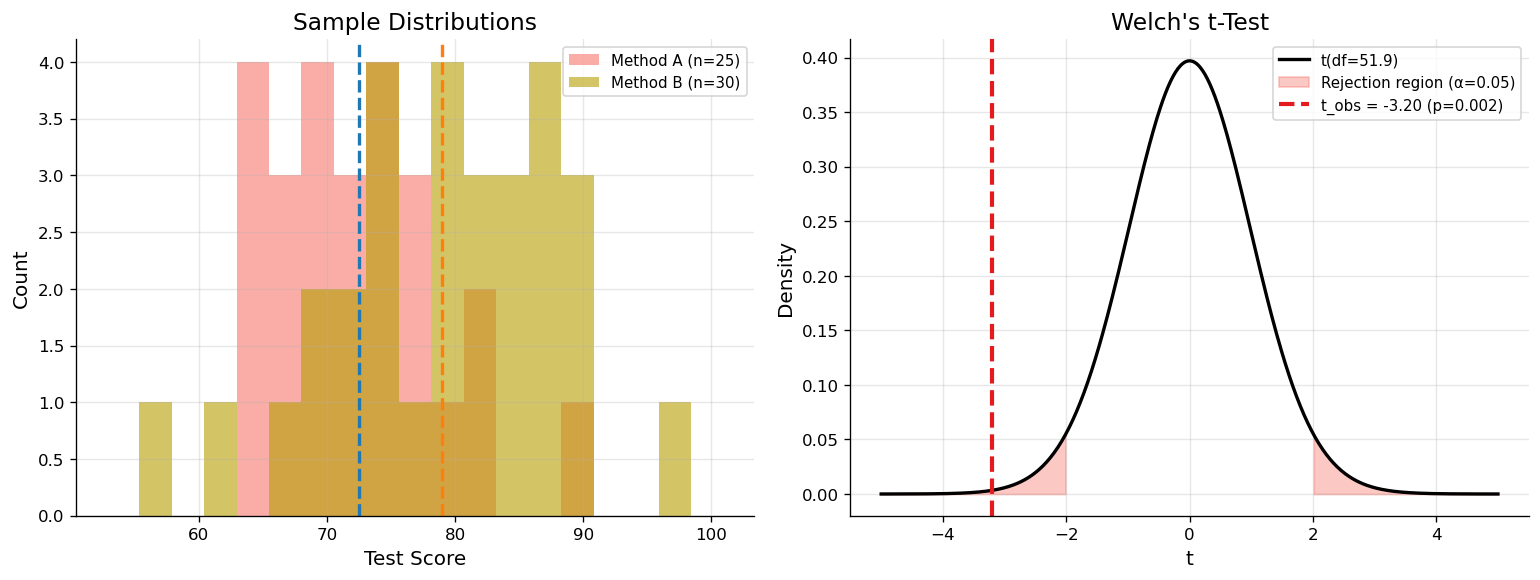

In [ ]:
# Visualise the two groups and the t-test result
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: histograms of the two samples
bins = np.linspace(
    min(method_A.min(), method_B.min()) - 5, max(method_A.max(), method_B.max()) + 5, 20
)
axes[0].hist(method_A, bins=bins, alpha=0.6, label=f"Method A (n={len(method_A)})")
axes[0].hist(method_B, bins=bins, alpha=0.6, label=f"Method B (n={len(method_B)})")
axes[0].axvline(method_A.mean(), color="#1f77b4", linewidth=2, linestyle="--")
axes[0].axvline(method_B.mean(), color="#ff7f0e", linewidth=2, linestyle="--")
axes[0].set_xlabel("Test Score")
axes[0].set_ylabel("Count")
axes[0].set_title("Sample Distributions")
axes[0].legend(fontsize=9)

# Right: t-distribution under H0 with observed value
x_t = np.linspace(-5, 5, 500)
pdf_t = stats.t.pdf(x_t, df=df_s)
axes[1].plot(x_t, pdf_t, "k-", linewidth=2, label=f"t(df={df_s:.1f})")

# Shade rejection regions
t_crit = stats.t.ppf(0.975, df=df_s)
mask_r = x_t >= t_crit
mask_l = x_t <= -t_crit
axes[1].fill_between(x_t[mask_r], pdf_t[mask_r], color="#F8766D", alpha=0.4)
axes[1].fill_between(
    x_t[mask_l],
    pdf_t[mask_l],
    color="#F8766D",
    alpha=0.4,
    label="Rejection region (\u03b1=0.05)",
)
axes[1].axvline(
    t_s,
    color="#E41A1C",
    linewidth=2.5,
    linestyle="--",
    label=f"t_obs = {t_s:.2f} (p={p_s:.3f})",
)
axes[1].set_xlabel("t")
axes[1].set_ylabel("Density")
axes[1].set_title("Welch's t-Test")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

---

## 5. Paired t-Test

### When Observations Are Paired

Sometimes the two samples are **not independent** — each observation in one sample has a natural partner in the other:

- Blood pressure **before** and **after** treatment (same patients)
- Test scores of students with method A and method B (same students, crossover design)
- Left eye vs. right eye measurements (same individuals)

Using a two-sample t-test here would be incorrect because it assumes independence. Instead, we use the **paired t-test**.

### The Key Insight

Let $(X_i, Y_i)$ be the paired observations. Define the **differences**:

$$D_i = X_i - Y_i, \qquad i = 1, \ldots, n$$

Then testing $H_0: \mu_X = \mu_Y$ is equivalent to testing $H_0: \mu_D = 0$. This reduces the problem to a **one-sample t-test on the differences**:

$$T = \frac{\bar{D}}{S_D / \sqrt{n}} \sim t_{n-1}$$

where $\bar{D}$ and $S_D$ are the mean and standard deviation of the differences.

**Why is this better?** By taking differences within each pair, we eliminate between-subject variability. If patients have very different baseline blood pressures, the individual measurements will have high variance, but the *changes* may be quite consistent. The paired test has greater power because $S_D$ is typically much smaller than the variation in the raw observations.

### Worked Example

A study measures reaction times (ms) of 12 subjects before and after drinking coffee:

In [ ]:
# Paired t-test example: reaction times before/after coffee
n_subjects = 12

# Simulate: baseline varies widely across subjects, but coffee effect is consistent
baseline = rng.normal(
    loc=280, scale=40, size=n_subjects
)  # wide between-subject variation
after_coffee = baseline + rng.normal(
    loc=-15, scale=8, size=n_subjects
)  # coffee speeds up by ~15ms

differences = after_coffee - baseline

print("Subject  |  Before  |  After  | Difference")
print("-" * 47)
for i in range(n_subjects):
    print(
        f"   {i + 1:2d}    |  {baseline[i]:6.1f}  | {after_coffee[i]:6.1f}  |  {differences[i]:+6.1f}"
    )
print("-" * 47)
print(
    f"  Mean   |  {baseline.mean():6.1f}  | {after_coffee.mean():6.1f}  |  {differences.mean():+6.1f}"
)
print(
    f"  Std    |  {baseline.std(ddof=1):6.1f}  | {after_coffee.std(ddof=1):6.1f}  |  {differences.std(ddof=1):+6.1f}"
)

Subject  |  Before  |  After  | Difference
-----------------------------------------------
    1    |   229.0  |  211.1  |   -17.9
    2    |   234.7  |  216.6  |   -18.1
    3    |   243.2  |  218.7  |   -24.6
    4    |   299.9  |  288.8  |   -11.1
    5    |   285.7  |  266.9  |   -18.8
    6    |   307.6  |  292.7  |   -14.9
    7    |   262.9  |  251.8  |   -11.2
    8    |   286.3  |  274.9  |   -11.4
    9    |   305.0  |  295.3  |    -9.7
   10    |   267.6  |  251.8  |   -15.8
   11    |   298.3  |  279.9  |   -18.4
   12    |   253.5  |  237.9  |   -15.6
-----------------------------------------------
  Mean   |   272.8  |  257.2  |   -15.6
  Std    |    28.2  |   30.6  |    +4.3


In [ ]:
# Paired t-test: from scratch (just a one-sample t-test on differences)
d_bar = differences.mean()
s_d = differences.std(ddof=1)
se_d = s_d / np.sqrt(n_subjects)
t_paired = d_bar / se_d
df_paired = n_subjects - 1
p_paired = 2 * stats.t.sf(abs(t_paired), df=df_paired)

print("=== Paired t-test (from scratch) ===")
print(f"Mean difference: {d_bar:.2f} ms")
print(f"Std of differences: {s_d:.2f}")
print(f"SE of mean difference: {se_d:.2f}")
print(f"t = {d_bar:.2f} / {se_d:.2f} = {t_paired:.4f}")
print(f"df = {df_paired}")
print(f"p-value (two-sided) = {p_paired:.6f}")

# scipy comparison
t_sp, p_sp = stats.ttest_rel(after_coffee, baseline)
print(f"\n=== scipy.stats.ttest_rel ===")
print(f"t = {t_sp:.4f}, p = {p_sp:.6f}")

# What if we (incorrectly) used an unpaired test?
t_wrong, p_wrong = stats.ttest_ind(after_coffee, baseline)
print(f"\n=== WRONG: unpaired t-test ===")
print(f"t = {t_wrong:.4f}, p = {p_wrong:.4f}")
print(f"\nThe paired test detects the effect (p={p_paired:.4f}) because it removes")
print(
    f"between-subject variability. The unpaired test misses it (p={p_wrong:.4f}) because"
)
print(f"the large between-subject variance swamps the treatment effect.")

=== Paired t-test (from scratch) ===
Mean difference: -15.61 ms
Std of differences: 4.29
SE of mean difference: 1.24
t = -15.61 / 1.24 = -12.6071
df = 11
p-value (two-sided) = 0.000000

=== scipy.stats.ttest_rel ===
t = -12.6071, p = 0.000000

=== WRONG: unpaired t-test ===
t = -1.2993, p = 0.2073

The paired test detects the effect (p=0.0000) because it removes
between-subject variability. The unpaired test misses it (p=0.2073) because
the large between-subject variance swamps the treatment effect.


This is a powerful demonstration: the same data gives opposite conclusions depending on whether we correctly account for the paired structure. The paired test works because the standard deviation of the differences ($S_D$) is much smaller than the standard deviations of the individual groups.

---

## 6. Chi-Square Goodness-of-Fit Test

### Setting

All the previous tests dealt with **continuous** data and tested hypotheses about means. The **chi-square test** handles **categorical** data — counts in categories.

We have $k$ categories. Under $H_0$, the probability of falling into category $j$ is $p_j$ (with $\sum p_j = 1$). We observe counts $O_1, O_2, \ldots, O_k$ from $n$ total observations. We want to test:

$$H_0: \text{The data follows the specified distribution } (p_1, \ldots, p_k)$$

### Derivation of the Test Statistic

Under $H_0$, the **expected count** in category $j$ is:

$$E_j = n \cdot p_j$$

The test statistic measures how much the observed counts deviate from the expected counts:

$$\chi^2 = \sum_{j=1}^{k} \frac{(O_j - E_j)^2}{E_j}$$

**Why this formula?** Consider $(O_j - E_j)^2$ — the squared deviation of the observed from expected. We divide by $E_j$ because a deviation of 5 is more surprising in a category with $E_j = 10$ than in one with $E_j = 1000$. The division normalises by the expected magnitude.

**Where does the $\chi^2$ distribution come from?** Under $H_0$, each $O_j$ is approximately normally distributed (by the CLT applied to binomial counts). So $(O_j - E_j) / \sqrt{E_j}$ is approximately $\mathcal{N}(0, 1)$. The sum of squared approximately-normal variables is approximately chi-squared. The constraint $\sum O_j = n$ removes one degree of freedom:

$$\chi^2 \underset{H_0}{\sim} \chi^2_{k-1}$$

The approximation works well when all $E_j \geq 5$ (a common rule of thumb).

**The test is always right-tailed:** large $\chi^2$ values indicate poor fit; small values indicate good fit. We reject if $\chi^2 > \chi^2_{\alpha, k-1}$.

### Worked Example: Is This Die Fair?

A die is rolled 120 times. If it's fair, we expect 20 rolls per face.

In [ ]:
# Die fairness example
# Simulate a slightly loaded die
true_probs = [0.12, 0.18, 0.15, 0.20, 0.17, 0.18]  # biased die
n_rolls = 120
observed = rng.multinomial(n_rolls, true_probs)
faces = np.arange(1, 7)

# Under H0 (fair die)
expected = np.full(6, n_rolls / 6)  # 20 each

print("Face     | Observed | Expected | (O-E)^2/E")
print("-" * 48)
chi2_components = (observed - expected) ** 2 / expected
for i in range(6):
    print(
        f"  {faces[i]}      |    {observed[i]:3d}   |   {expected[i]:.1f}   |   {chi2_components[i]:.4f}"
    )
print("-" * 48)
print(
    f"Total    |    {observed.sum():3d}   |  {expected.sum():.1f}   |   {chi2_components.sum():.4f}"
)

Face     | Observed | Expected | (O-E)^2/E
------------------------------------------------
  1      |     13   |   20.0   |   2.4500
  2      |     16   |   20.0   |   0.8000
  3      |     15   |   20.0   |   1.2500
  4      |     35   |   20.0   |   11.2500
  5      |     24   |   20.0   |   0.8000
  6      |     17   |   20.0   |   0.4500
------------------------------------------------
Total    |    120   |  120.0   |   17.0000


In [ ]:
def chi2_goodness_of_fit_scratch(observed, expected):
    """
    Chi-square goodness-of-fit test from scratch.

    Parameters
    ----------
    observed : array-like
        Observed counts per category.
    expected : array-like
        Expected counts per category under H0.

    Returns
    -------
    chi2_stat, p_value, df
    """
    O = np.asarray(observed, dtype=float)
    E = np.asarray(expected, dtype=float)
    k = len(O)
    df = k - 1

    chi2_stat = np.sum((O - E) ** 2 / E)
    p_value = stats.chi2.sf(chi2_stat, df=df)  # right-tail

    return chi2_stat, p_value, df


# From scratch
chi2_s, p_s, df_s = chi2_goodness_of_fit_scratch(observed, expected)
print(f"From scratch: chi2 = {chi2_s:.4f}, df = {df_s}, p = {p_s:.4f}")

# scipy comparison
chi2_sp, p_sp = stats.chisquare(observed, f_exp=expected)
print(f"scipy:        chi2 = {chi2_sp:.4f},            p = {p_sp:.4f}")

alpha = 0.05
print(
    f"\nDecision at alpha = {alpha}: {'REJECT H0 (die is not fair)' if p_s < alpha else 'Fail to reject H0 (no evidence die is unfair)'}"
)

From scratch: chi2 = 17.0000, df = 5, p = 0.0045
scipy:        chi2 = 17.0000,            p = 0.0045

Decision at alpha = 0.05: REJECT H0 (die is not fair)


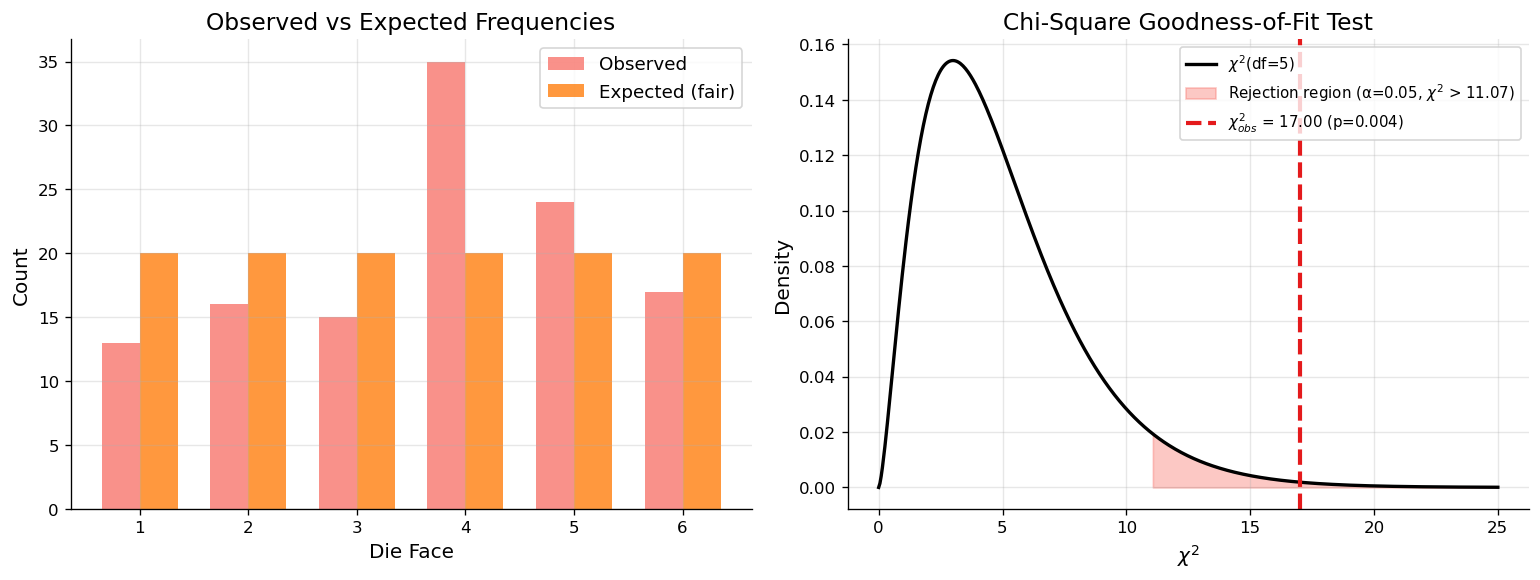

In [ ]:
# Visualise: observed vs expected counts
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: bar chart
bar_width = 0.35
x_pos = np.arange(6)
axes[0].bar(x_pos - bar_width / 2, observed, bar_width, label="Observed", alpha=0.8)
axes[0].bar(
    x_pos + bar_width / 2,
    expected,
    bar_width,
    label="Expected (fair)",
    alpha=0.8,
    color="#ff7f0e",
)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([str(f) for f in faces])
axes[0].set_xlabel("Die Face")
axes[0].set_ylabel("Count")
axes[0].set_title("Observed vs Expected Frequencies")
axes[0].legend()

# Right: chi-square distribution with observed value
x_chi = np.linspace(0, 25, 500)
pdf_chi = stats.chi2.pdf(x_chi, df=df_s)
axes[1].plot(x_chi, pdf_chi, "k-", linewidth=2, label=f"$\\chi^2$(df={df_s})")

# Shade rejection region
chi2_crit = stats.chi2.ppf(0.95, df=df_s)
mask = x_chi >= chi2_crit
axes[1].fill_between(
    x_chi[mask],
    pdf_chi[mask],
    color="#F8766D",
    alpha=0.4,
    label=f"Rejection region (\u03b1=0.05, $\\chi^2$ > {chi2_crit:.2f})",
)
axes[1].axvline(
    chi2_s,
    color="#E41A1C",
    linewidth=2.5,
    linestyle="--",
    label=f"$\\chi^2_{{obs}}$ = {chi2_s:.2f} (p={p_s:.3f})",
)
axes[1].set_xlabel("$\\chi^2$")
axes[1].set_ylabel("Density")
axes[1].set_title("Chi-Square Goodness-of-Fit Test")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

---

## 7. Chi-Square Test of Independence

### Setting

This is a different use of the chi-square statistic. Instead of testing whether data matches a specified distribution, we test whether two categorical variables are **independent**.

The data is organised in a **contingency table** with $r$ rows and $c$ columns:

$$H_0: \text{The two variables are independent}$$
$$H_1: \text{The two variables are associated}$$

### Expected Frequencies Under Independence

If the variables are independent, $P(\text{row } i \cap \text{col } j) = P(\text{row } i) \cdot P(\text{col } j)$.

We estimate these marginal probabilities from the data:
- $\hat{P}(\text{row } i) = R_i / n$ where $R_i$ is the row total
- $\hat{P}(\text{col } j) = C_j / n$ where $C_j$ is the column total

So the expected count in cell $(i, j)$ under independence is:

$$E_{ij} = n \cdot \frac{R_i}{n} \cdot \frac{C_j}{n} = \frac{R_i \cdot C_j}{n}$$

**In plain language:** If smoking and lung cancer are independent, then the proportion of smokers among cancer patients should be the same as the proportion of smokers in the whole sample. The expected count tells us what the cell counts *would be* if there were no association.

### Test Statistic and Degrees of Freedom

$$\chi^2 = \sum_{i=1}^{r} \sum_{j=1}^{c} \frac{(O_{ij} - E_{ij})^2}{E_{ij}} \sim \chi^2_{(r-1)(c-1)}$$

The degrees of freedom are $(r-1)(c-1)$. Why? The table has $r \times c$ cells, but the row totals and column totals impose $r + c - 1$ independent constraints (the $-1$ is because the grand total is fixed). So $df = rc - 1 - (r - 1) - (c - 1) = (r-1)(c-1)$.

### Worked Example: Treatment vs. Outcome

A clinical trial records whether patients who received Drug A, Drug B, or Placebo showed improvement:

In [ ]:
# Contingency table: Treatment vs Outcome
# Rows: Drug A, Drug B, Placebo
# Cols: Improved, No Change, Worsened

observed_table = np.array(
    [
        [45, 12, 3],  # Drug A
        [38, 15, 7],  # Drug B
        [25, 22, 13],  # Placebo
    ]
)

row_labels = ["Drug A", "Drug B", "Placebo"]
col_labels = ["Improved", "No Change", "Worsened"]

n_total = observed_table.sum()
row_totals = observed_table.sum(axis=1)
col_totals = observed_table.sum(axis=0)

print("Observed Counts:")
print(
    f"{'':>12s} | {'Improved':>9s} | {'No Change':>9s} | {'Worsened':>9s} | {'Total':>6s}"
)
print("-" * 60)
for i, label in enumerate(row_labels):
    print(
        f"{label:>12s} | {observed_table[i, 0]:9d} | {observed_table[i, 1]:9d} | {observed_table[i, 2]:9d} | {row_totals[i]:6d}"
    )
print("-" * 60)
print(
    f"{'Total':>12s} | {col_totals[0]:9d} | {col_totals[1]:9d} | {col_totals[2]:9d} | {n_total:6d}"
)

Observed Counts:
             |  Improved | No Change |  Worsened |  Total
------------------------------------------------------------
      Drug A |        45 |        12 |         3 |     60
      Drug B |        38 |        15 |         7 |     60
     Placebo |        25 |        22 |        13 |     60
------------------------------------------------------------
       Total |       108 |        49 |        23 |    180


In [ ]:
def chi2_independence_scratch(observed_table):
    """
    Chi-square test of independence from scratch.

    Parameters
    ----------
    observed_table : 2D array
        Contingency table of observed counts.

    Returns
    -------
    chi2_stat, p_value, df, expected_table
    """
    O = np.asarray(observed_table, dtype=float)
    r, c = O.shape
    n = O.sum()

    row_totals = O.sum(axis=1)
    col_totals = O.sum(axis=0)

    # Expected counts under independence: E_ij = R_i * C_j / n
    E = np.outer(row_totals, col_totals) / n

    df = (r - 1) * (c - 1)
    chi2_stat = np.sum((O - E) ** 2 / E)
    p_value = stats.chi2.sf(chi2_stat, df=df)

    return chi2_stat, p_value, df, E


# From scratch
chi2_s, p_s, df_s, expected_ind = chi2_independence_scratch(observed_table)
print("Expected Counts (under independence):")
print(f"{'':>12s} | {'Improved':>9s} | {'No Change':>9s} | {'Worsened':>9s}")
print("-" * 52)
for i, label in enumerate(row_labels):
    print(
        f"{label:>12s} | {expected_ind[i, 0]:9.2f} | {expected_ind[i, 1]:9.2f} | {expected_ind[i, 2]:9.2f}"
    )

print(f"\nFrom scratch: chi2 = {chi2_s:.4f}, df = {df_s}, p = {p_s:.6f}")

# scipy comparison
chi2_sp, p_sp, dof_sp, exp_sp = stats.chi2_contingency(observed_table)
print(f"scipy:        chi2 = {chi2_sp:.4f}, df = {dof_sp}, p = {p_sp:.6f}")

print(
    f"\nDecision at alpha = 0.05: {'REJECT H0' if p_s < 0.05 else 'Fail to reject H0'}"
)
print(
    "Treatment and outcome are NOT independent -- there is a significant association."
)

Expected Counts (under independence):
             |  Improved | No Change |  Worsened
----------------------------------------------------
      Drug A |     36.00 |     16.33 |      7.67
      Drug B |     36.00 |     16.33 |      7.67
     Placebo |     36.00 |     16.33 |      7.67

From scratch: chi2 = 15.5554, df = 4, p = 0.003678
scipy:        chi2 = 15.5554, df = 4, p = 0.003678

Decision at alpha = 0.05: REJECT H0
Treatment and outcome are NOT independent -- there is a significant association.


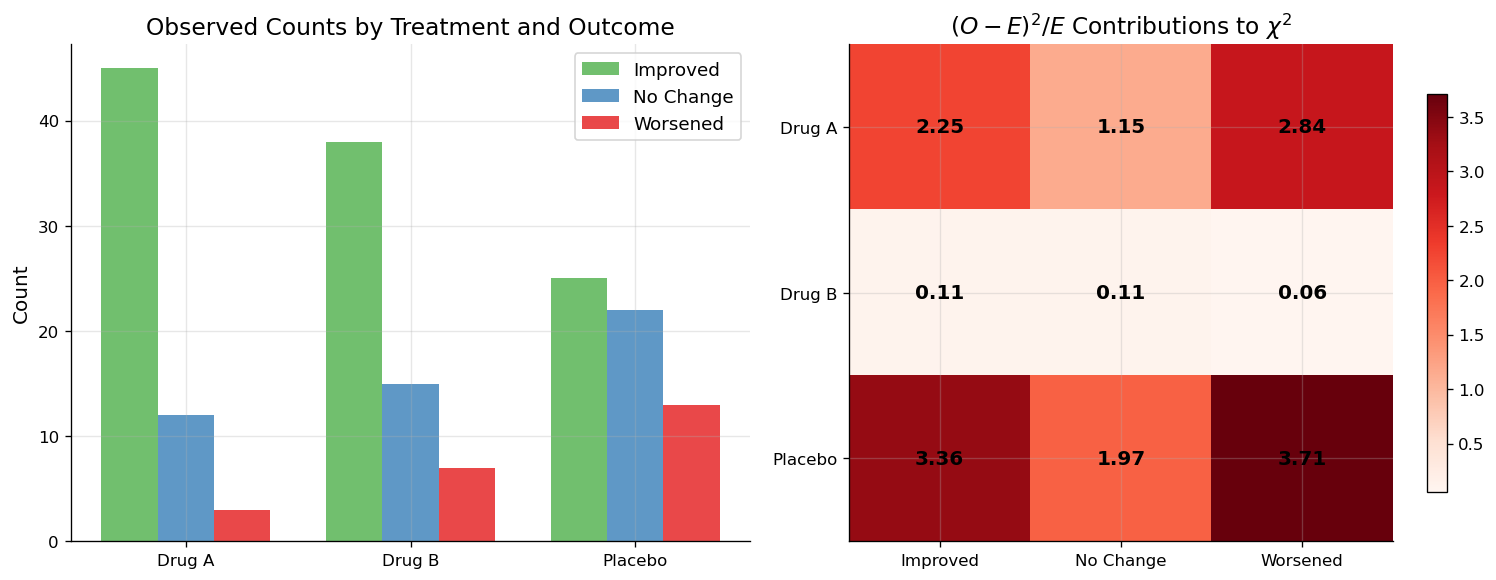

The heatmap shows which cells contribute most to the chi-square statistic.
Large values indicate the biggest deviations from what independence predicts.


In [ ]:
# Visualise the contingency table
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: grouped bar chart
x_pos = np.arange(len(row_labels))
width = 0.25
for j, (col_lbl, color) in enumerate(
    zip(col_labels, ["#4DAF4A", "#377EB8", "#E41A1C"])
):
    axes[0].bar(
        x_pos + j * width,
        observed_table[:, j],
        width,
        label=col_lbl,
        color=color,
        alpha=0.8,
    )
axes[0].set_xticks(x_pos + width)
axes[0].set_xticklabels(row_labels)
axes[0].set_ylabel("Count")
axes[0].set_title("Observed Counts by Treatment and Outcome")
axes[0].legend()

# Right: heatmap of (O - E)^2 / E contributions
contributions = (observed_table - expected_ind) ** 2 / expected_ind
im = axes[1].imshow(contributions, cmap="Reds", aspect="auto")
axes[1].set_xticks(range(len(col_labels)))
axes[1].set_xticklabels(col_labels)
axes[1].set_yticks(range(len(row_labels)))
axes[1].set_yticklabels(row_labels)
axes[1].set_title("$(O - E)^2 / E$ Contributions to $\\chi^2$")
for i in range(len(row_labels)):
    for j in range(len(col_labels)):
        axes[1].text(
            j,
            i,
            f"{contributions[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=12,
            fontweight="bold",
        )
fig.colorbar(im, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.show()

print("The heatmap shows which cells contribute most to the chi-square statistic.")
print("Large values indicate the biggest deviations from what independence predicts.")

---

## 8. F-Test for Equality of Variances

### Setting

All previous tests compared **means** or **frequencies**. The F-test compares **variances** of two populations:

$$H_0: \sigma_1^2 = \sigma_2^2 \qquad \text{vs.} \qquad H_1: \sigma_1^2 \neq \sigma_2^2$$

### Derivation

Let $X_1, \ldots, X_{n_1} \sim \mathcal{N}(\mu_1, \sigma_1^2)$ and $Y_1, \ldots, Y_{n_2} \sim \mathcal{N}(\mu_2, \sigma_2^2)$ be independent samples.

Recall that $\frac{(n_k - 1) S_k^2}{\sigma_k^2} \sim \chi^2_{n_k - 1}$ for normal populations. Under $H_0$ ($\sigma_1^2 = \sigma_2^2$), the ratio of sample variances:

$$F = \frac{S_1^2}{S_2^2} = \frac{\chi^2_{n_1-1} / (n_1 - 1)}{\chi^2_{n_2-1} / (n_2 - 1)} \sim F_{n_1-1,\, n_2-1}$$

This is the **F-distribution** with $d_1 = n_1 - 1$ and $d_2 = n_2 - 1$ degrees of freedom. It's defined as the ratio of two independent chi-squared random variables, each divided by their degrees of freedom.

**In plain language:** If the two populations have the same spread, the ratio of sample variances should be close to 1. If it's much larger or much smaller than 1, we have evidence that the variances differ.

### Properties of the F-Distribution

- $F > 0$ always (it's a ratio of positive quantities)
- Under $H_0$, $E[F] \approx 1$ (exactly $d_2 / (d_2 - 2)$ for $d_2 > 2$)
- The distribution is **right-skewed**
- $1/F \sim F_{d_2, d_1}$ (swapping the degrees of freedom)

### Connection to ANOVA (Preview)

The F-distribution plays a central role in **ANOVA** (Analysis of Variance), which we'll cover in Module 08. In one-way ANOVA, the F-statistic compares:

$$F = \frac{\text{between-group variance}}{\text{within-group variance}}$$

If the group means are all equal, this ratio has an F-distribution. The F-test for equality of two variances is the simplest special case.

### Important Caveat

The F-test for equality of variances is **very sensitive to non-normality**. Even mild departures from normality can produce misleading results. For this reason, **Levene's test** or **Bartlett's test** are often preferred in practice. When deciding between pooled and Welch's t-test, many practitioners simply default to Welch's rather than using an F-test to check equal variances.

### Worked Example

In [19]:
# F-test example: comparing variability of two machines
machine_A = rng.normal(loc=50, scale=3.0, size=20)
machine_B = rng.normal(loc=50, scale=5.5, size=25)

s1_sq = machine_A.var(ddof=1)
s2_sq = machine_B.var(ddof=1)
n1, n2 = len(machine_A), len(machine_B)

print(f"Machine A: n = {n1}, s^2 = {s1_sq:.4f}, s = {np.sqrt(s1_sq):.4f}")
print(f"Machine B: n = {n2}, s^2 = {s2_sq:.4f}, s = {np.sqrt(s2_sq):.4f}")

Machine A: n = 20, s^2 = 6.6890, s = 2.5863
Machine B: n = 25, s^2 = 42.1227, s = 6.4902


In [ ]:
def f_test_equality_of_variances(data1, data2, alternative="two-sided"):
    """
    F-test for equality of two variances (from scratch).

    Assumes both populations are normally distributed.

    Parameters
    ----------
    data1, data2 : array-like
        Two independent samples.
    alternative : str
        'two-sided', 'greater' (var1 > var2), or 'less' (var1 < var2).

    Returns
    -------
    f_stat, p_value, df1, df2
    """
    d1 = np.asarray(data1, dtype=float)
    d2 = np.asarray(data2, dtype=float)
    n1, n2 = len(d1), len(d2)
    df1, df2 = n1 - 1, n2 - 1
    s1_sq = d1.var(ddof=1)
    s2_sq = d2.var(ddof=1)

    f_stat = s1_sq / s2_sq

    if alternative == "two-sided":
        # Two-sided: probability of being as extreme in either direction
        p_right = stats.f.sf(f_stat, df1, df2)
        p_left = stats.f.cdf(f_stat, df1, df2)
        p_value = 2 * min(p_right, p_left)
    elif alternative == "greater":
        p_value = stats.f.sf(f_stat, df1, df2)
    elif alternative == "less":
        p_value = stats.f.cdf(f_stat, df1, df2)
    else:
        raise ValueError(f"Unknown alternative: {alternative}")

    return f_stat, p_value, df1, df2


# From scratch
f_stat, p_val, df1, df2 = f_test_equality_of_variances(machine_A, machine_B)
print(f"F = s1^2 / s2^2 = {s1_sq:.4f} / {s2_sq:.4f} = {f_stat:.4f}")
print(f"df1 = {df1}, df2 = {df2}")
print(f"p-value (two-sided) = {p_val:.4f}")
print(
    f"\nDecision at alpha = 0.05: {'REJECT H0 (variances differ)' if p_val < 0.05 else 'Fail to reject H0'}"
)

F = s1^2 / s2^2 = 6.6890 / 42.1227 = 0.1588
df1 = 19, df2 = 24
p-value (two-sided) = 0.0001

Decision at alpha = 0.05: REJECT H0 (variances differ)


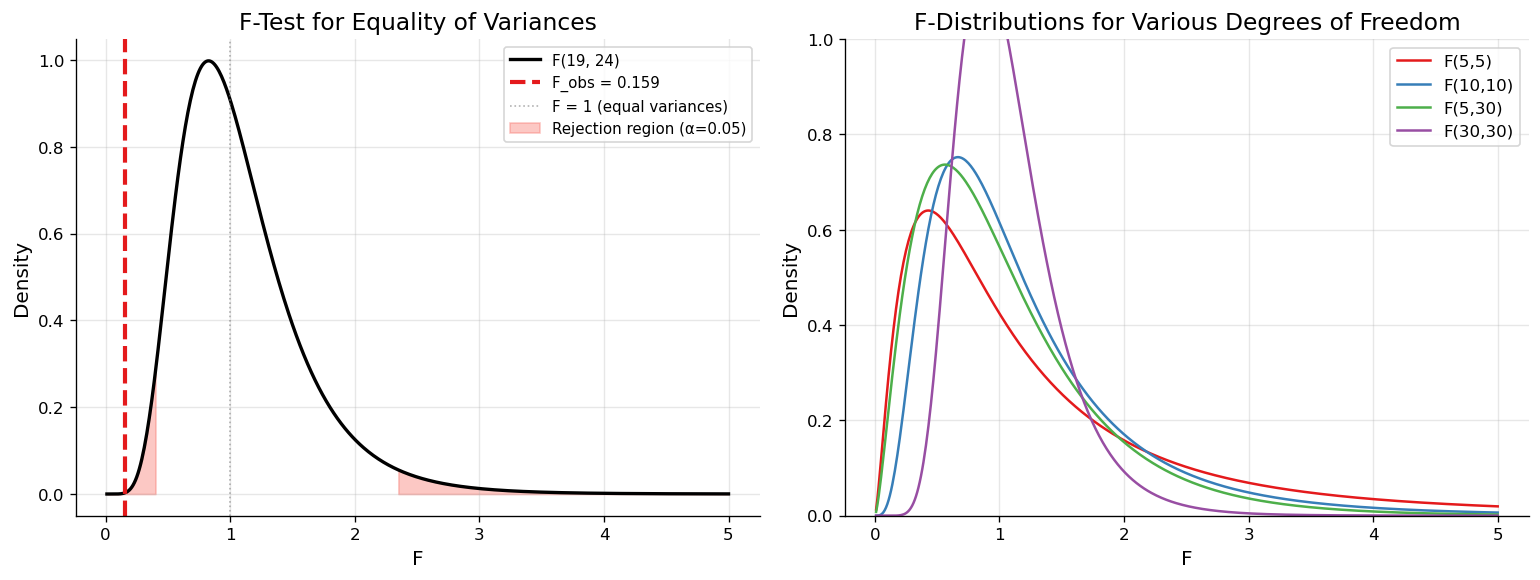

In [ ]:
# Visualise F-distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: F-distribution with observed value
x_f = np.linspace(0.01, 5, 500)
pdf_f = stats.f.pdf(x_f, df1, df2)
axes[0].plot(x_f, pdf_f, "k-", linewidth=2, label=f"F({df1}, {df2})")
axes[0].axvline(
    f_stat,
    color="#E41A1C",
    linewidth=2.5,
    linestyle="--",
    label=f"F_obs = {f_stat:.3f}",
)
axes[0].axvline(
    1.0,
    color="gray",
    linewidth=1,
    linestyle=":",
    alpha=0.6,
    label="F = 1 (equal variances)",
)

# Shade rejection regions
f_crit_upper = stats.f.ppf(0.975, df1, df2)
f_crit_lower = stats.f.ppf(0.025, df1, df2)
mask_upper = x_f >= f_crit_upper
mask_lower = x_f <= f_crit_lower
axes[0].fill_between(x_f[mask_upper], pdf_f[mask_upper], color="#F8766D", alpha=0.4)
axes[0].fill_between(
    x_f[mask_lower],
    pdf_f[mask_lower],
    color="#F8766D",
    alpha=0.4,
    label="Rejection region (\u03b1=0.05)",
)

axes[0].set_xlabel("F")
axes[0].set_ylabel("Density")
axes[0].set_title("F-Test for Equality of Variances")
axes[0].legend(fontsize=9)

# Right: different F-distributions
f_params = [(5, 5), (10, 10), (5, 30), (30, 30)]
colors = ["#E41A1C", "#377EB8", "#4DAF4A", "#984EA3"]
for (d1, d2), c in zip(f_params, colors):
    axes[1].plot(
        x_f, stats.f.pdf(x_f, d1, d2), color=c, linewidth=1.5, label=f"F({d1},{d2})"
    )
axes[1].set_xlabel("F")
axes[1].set_ylabel("Density")
axes[1].set_title("F-Distributions for Various Degrees of Freedom")
axes[1].legend(fontsize=10)
axes[1].set_ylim(0, 1.0)

plt.tight_layout()
plt.show()

---

## 9. Summary: Which Test for Which Situation?

The following table summarises the tests covered in this notebook and when to use each one.

| Test                         | Data type            | What it tests                  | Key assumption                     | Test statistic                                                             | Distribution under $H_0$ |
|------------------------------|----------------------|--------------------------------|------------------------------------|----------------------------------------------------------------------------|--------------------------|
| **One-sample z**             | Continuous           | $\mu = \mu_0$                  | $\sigma$ known                     | $Z = \frac{\bar{X} - \mu_0}{\sigma/\sqrt{n}}$                              | $\mathcal{N}(0,1)$       |
| **Two-sample z**             | Continuous           | $\mu_1 = \mu_2$                | Both $\sigma_i$ known              | $Z = \frac{\bar{X}_1 - \bar{X}_2}{\sqrt{\sigma_1^2/n_1 + \sigma_2^2/n_2}}$ | $\mathcal{N}(0,1)$       |
| **One-sample t**             | Continuous           | $\mu = \mu_0$                  | $\sigma$ unknown, approx. normal   | $T = \frac{\bar{X} - \mu_0}{S/\sqrt{n}}$                                   | $t_{n-1}$                |
| **Two-sample t (pooled)**    | Continuous           | $\mu_1 = \mu_2$                | $\sigma_1 = \sigma_2$ (unknown)    | $T = \frac{\bar{X}_1 - \bar{X}_2}{S_p\sqrt{1/n_1 + 1/n_2}}$                | $t_{n_1+n_2-2}$          |
| **Two-sample t (Welch)**     | Continuous           | $\mu_1 = \mu_2$                | $\sigma_1 \neq \sigma_2$ (unknown) | $T = \frac{\bar{X}_1 - \bar{X}_2}{\sqrt{S_1^2/n_1 + S_2^2/n_2}}$           | $t_\nu$ (Satterthwaite)  |
| **Paired t**                 | Continuous, paired   | $\mu_D = 0$                    | Paired observations                | $T = \frac{\bar{D}}{S_D/\sqrt{n}}$                                         | $t_{n-1}$                |
| **$\chi^2$ goodness-of-fit** | Categorical          | Matches specified distribution | $E_j \geq 5$                       | $\sum \frac{(O_j - E_j)^2}{E_j}$                                           | $\chi^2_{k-1}$           |
| **$\chi^2$ independence**    | Categorical (2 vars) | Variables are independent      | $E_{ij} \geq 5$                    | $\sum\sum \frac{(O_{ij} - E_{ij})^2}{E_{ij}}$                              | $\chi^2_{(r-1)(c-1)}$    |
| **F-test (variances)**       | Continuous           | $\sigma_1^2 = \sigma_2^2$      | Normal populations                 | $F = S_1^2 / S_2^2$                                                        | $F_{n_1-1, n_2-1}$       |

### Practical Decision Flowchart

1. **What kind of data?** Continuous → z/t/F tests. Categorical → chi-square test.
2. **Comparing means?** One group → one-sample test. Two groups → two-sample test. Paired data → paired test.
3. **Is $\sigma$ known?** Yes → z-test (rare). No → t-test (common).
4. **Two-sample t: equal variances?** Unsure → use Welch's (safe default).
5. **Comparing variances?** → F-test (but check normality first).
6. **Categorical: one variable?** → goodness-of-fit. **Two variables?** → test of independence.

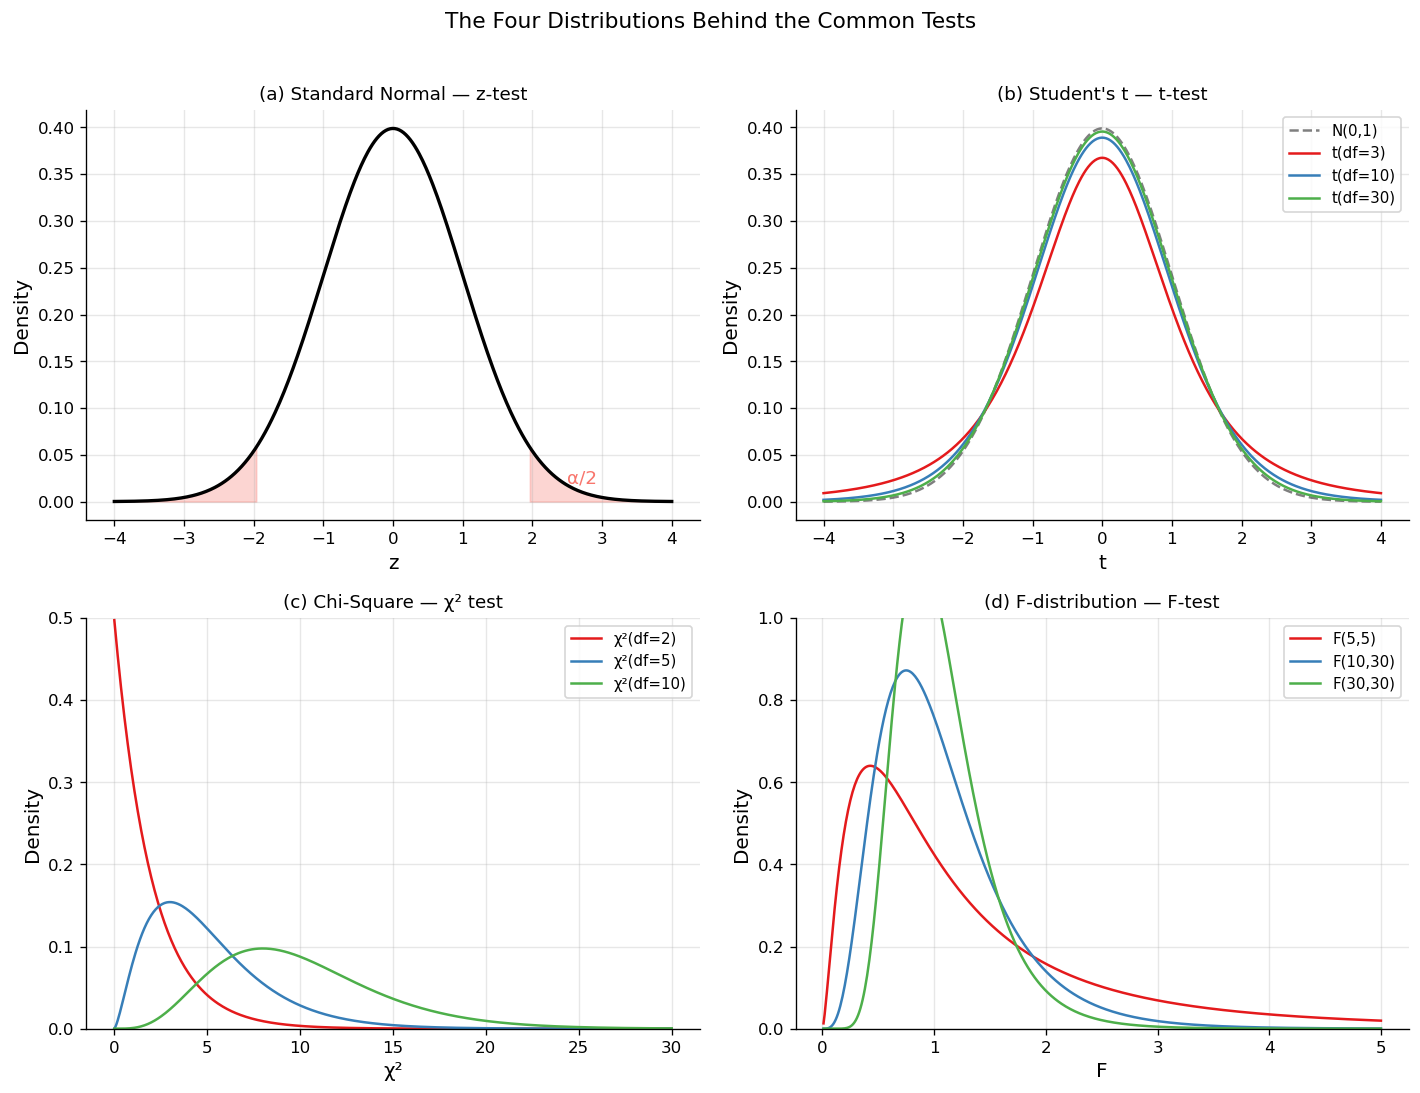

In [ ]:
# Side-by-side comparison of all four distributions used in these tests
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# (a) Standard Normal (z-test)
x = np.linspace(-4, 4, 500)
axes[0, 0].plot(x, stats.norm.pdf(x), "k-", linewidth=2)
axes[0, 0].fill_between(
    x[x >= 1.96], stats.norm.pdf(x[x >= 1.96]), alpha=0.3, color="#F8766D"
)
axes[0, 0].fill_between(
    x[x <= -1.96], stats.norm.pdf(x[x <= -1.96]), alpha=0.3, color="#F8766D"
)
axes[0, 0].set_title("(a) Standard Normal \u2014 z-test", fontsize=11)
axes[0, 0].set_xlabel("z")
axes[0, 0].annotate("\u03b1/2", xy=(2.5, 0.02), fontsize=11, color="#F8766D")

# (b) t-distribution (t-test)
axes[0, 1].plot(x, stats.norm.pdf(x), "k--", linewidth=1.5, alpha=0.5, label="N(0,1)")
for df_val, c in zip([3, 10, 30], ["#E41A1C", "#377EB8", "#4DAF4A"]):
    axes[0, 1].plot(
        x, stats.t.pdf(x, df_val), color=c, linewidth=1.5, label=f"t(df={df_val})"
    )
axes[0, 1].set_title("(b) Student's t \u2014 t-test", fontsize=11)
axes[0, 1].set_xlabel("t")
axes[0, 1].legend(fontsize=9)

# (c) Chi-square distribution
x_chi = np.linspace(0.01, 30, 500)
for df_val, c in zip([2, 5, 10], ["#E41A1C", "#377EB8", "#4DAF4A"]):
    axes[1, 0].plot(
        x_chi,
        stats.chi2.pdf(x_chi, df_val),
        color=c,
        linewidth=1.5,
        label=f"\u03c7\u00b2(df={df_val})",
    )
axes[1, 0].set_title("(c) Chi-Square \u2014 \u03c7\u00b2 test", fontsize=11)
axes[1, 0].set_xlabel("\u03c7\u00b2")
axes[1, 0].legend(fontsize=9)
axes[1, 0].set_ylim(0, 0.5)

# (d) F-distribution
x_f = np.linspace(0.01, 5, 500)
for (d1, d2), c in zip([(5, 5), (10, 30), (30, 30)], ["#E41A1C", "#377EB8", "#4DAF4A"]):
    axes[1, 1].plot(
        x_f, stats.f.pdf(x_f, d1, d2), color=c, linewidth=1.5, label=f"F({d1},{d2})"
    )
axes[1, 1].set_title("(d) F-distribution \u2014 F-test", fontsize=11)
axes[1, 1].set_xlabel("F")
axes[1, 1].legend(fontsize=9)
axes[1, 1].set_ylim(0, 1.0)

for ax in axes.flat:
    ax.set_ylabel("Density")

plt.suptitle("The Four Distributions Behind the Common Tests", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---

## Exercises

**Exercise 2.1 (z-test).** A cereal manufacturer claims boxes contain $\mu_0 = 400$ g on average. From quality records, $\sigma = 12$ g. A consumer group weighs $n = 50$ boxes and finds $\bar{x} = 396.5$ g. Perform a two-sided z-test at $\alpha = 0.01$. State your hypotheses, compute the test statistic and p-value, and give a clear conclusion. What is the 99% confidence interval for $\mu$?

**Exercise 2.2 (Two-sample z-test).** Two coffee roasters claim identical mean bean weight. Historical data gives $\sigma_1 = 1.5$ g, $\sigma_2 = 1.8$ g. Samples: $n_1 = 40$, $\bar{x}_1 = 10.3$ g; $n_2 = 45$, $\bar{x}_2 = 10.8$ g. Test $H_0: \mu_1 = \mu_2$ at $\alpha = 0.05$. Compute both by hand and using the from-scratch function.

**Exercise 2.3 (One-sample t-test).** A random sample of 20 students scores on an exam:

```python
scores = [72, 85, 65, 78, 90, 68, 74, 82, 88, 76,
          70, 80, 84, 73, 79, 86, 71, 77, 83, 69]
```

Test whether the population mean differs from 75. Perform the test from scratch and verify with `scipy.stats.ttest_1samp`. Compute the 95% confidence interval. If a z-test (pretending $s = \sigma$) gave a different conclusion, explain why.

**Exercise 2.4 (Welch's vs pooled).** Generate two samples:
- Group A: $n_1 = 15$ from $\mathcal{N}(50, 4^2)$
- Group B: $n_2 = 15$ from $\mathcal{N}(50, 12^2)$

Perform both a pooled and Welch's t-test. Then repeat with equal variances ($\sigma_1 = \sigma_2 = 8$). Discuss: when do the two tests agree? When do they disagree? Which is safer as a default?

**Exercise 2.5 (Chi-square goodness-of-fit).** A survey asks 200 people their favourite season. Results: Spring=42, Summer=68, Autumn=50, Winter=40. Test whether preferences are uniformly distributed ($p_j = 0.25$ each) at $\alpha = 0.05$. Then test against the alternative that summer is preferred 35% of the time and each other season 21.67%. Which model fits better?

**Exercise 2.6 (Full analysis).** A researcher collects the following data on study method (Flashcards, Reading, Practice Problems) and exam outcome (Pass, Fail):

|            | Pass | Fail |
|------------|------|------|
| Flashcards | 38   | 12   |
| Reading    | 30   | 20   |
| Practice   | 42   | 8    |

Perform a chi-square test of independence. Compute expected frequencies, the test statistic, and p-value both from scratch and with scipy. Which cells contribute most to $\chi^2$? What does this tell you about which study method is most/least effective?

---

## Key Takeaways

1. The **z-test** applies when $\sigma$ is known (rare in practice). The test statistic $Z = (\bar{X} - \mu_0) / (\sigma / \sqrt{n})$ follows a standard normal under $H_0$.
2. The **t-test** replaces $\sigma$ with the sample standard deviation $s$, which adds uncertainty. The test statistic follows a t-distribution with heavier tails, making the test appropriately more conservative.
3. **Degrees of freedom** reflect the number of independent pieces of information used to estimate $\sigma$. More df $\Rightarrow$ the t-distribution approaches the normal.
4. **Welch's t-test** is the safe default for two-sample comparisons — it handles unequal variances and performs nearly as well as the pooled test when variances are actually equal.
5. The **paired t-test** is a one-sample t-test on within-pair differences. It is far more powerful than an unpaired test when observations are naturally paired, because it eliminates between-subject variability.
6. The **chi-square goodness-of-fit test** checks whether categorical data matches a hypothesised distribution. The statistic $\sum (O - E)^2 / E$ measures the discrepancy.
7. The **chi-square test of independence** checks whether two categorical variables are associated, using expected counts derived from marginal totals.
8. The **F-test** compares variances via their ratio. It is highly sensitive to non-normality and underpins the ANOVA framework (Module 08).
9. Always choose the test that matches your **data structure** (paired vs independent, continuous vs categorical) and **assumptions** (known vs unknown $\sigma$, equal vs unequal variances).
10. Every test follows the same logic: assume $H_0$, compute how extreme the data is, and reject if it's too surprising.

**Next:** [03_errors_and_power.ipynb](03_errors_and_power.ipynb) — Type I and Type II errors, statistical power, sample size determination, and the relationship between effect size, sample size, and power.

In [23]:
cfg.save_gifs(clean=True)

  No new GIFs to save.
